In [72]:
import sim
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [143]:
all_results = []

ev_scheme = "priority"
for i in range(1, 26):
    current_sim = sim.ParkingSimulation(
        num_regular_spots=26-i, 
        num_ev_spots=i, 
        ev_scheme=ev_scheme, 
        static_pricing=True, 
        alpha=1.0, 
        base_rate=1.5
    )
    
    current_sim.run(visualize=False)
    
    all_results.append({
        "ev_spots": i,
        "ice_spots": 26-i,
        "ice_revenue": current_sim.revenue_ice,
        "ev_parking_revenue": current_sim.revenue_ev_parking,
        "ev_charging_revenue":  current_sim.revenue_ev_charging,
        "accepted_ice": current_sim.accepted_ice,
        "accepted_ev": current_sim.accepted_ev,
        "rejected_ice_full": current_sim.rejected_ice_full,
        "rejected_ev_full": current_sim.rejected_ev_full,
        "rejected_ice_price": current_sim.rejected_ice_price,
        "rejected_ev_price": current_sim.rejected_ev_price,
        "cost": current_sim.setup_cost
        
    })

In [144]:
df = pd.DataFrame(all_results)
df['total_revenue'] = df['ice_revenue'] + df['ev_parking_revenue'] + df['ev_charging_revenue']
df['ev_total_revenue'] = df['ev_parking_revenue'] + df['ev_charging_revenue']
df['yearly_rev'] = 52 * df['total_revenue']
df['accepted_ratio_full'] = (df['accepted_ice'] + df['accepted_ev'])/(df['accepted_ice'] + df['accepted_ev'] + df['rejected_ice_full'] + df['rejected_ev_full']+ df['rejected_ice_price'] + df['rejected_ev_price']) * 100
df['accepted_ice_full'] = (df['accepted_ice'])/(df['accepted_ice'] + df['rejected_ice_full'] + df['rejected_ice_price']) * 100
df['accepted_ev_full'] = (df['accepted_ev'])/(df['accepted_ev'] + df['rejected_ev_full'] + df['rejected_ev_price']) * 100

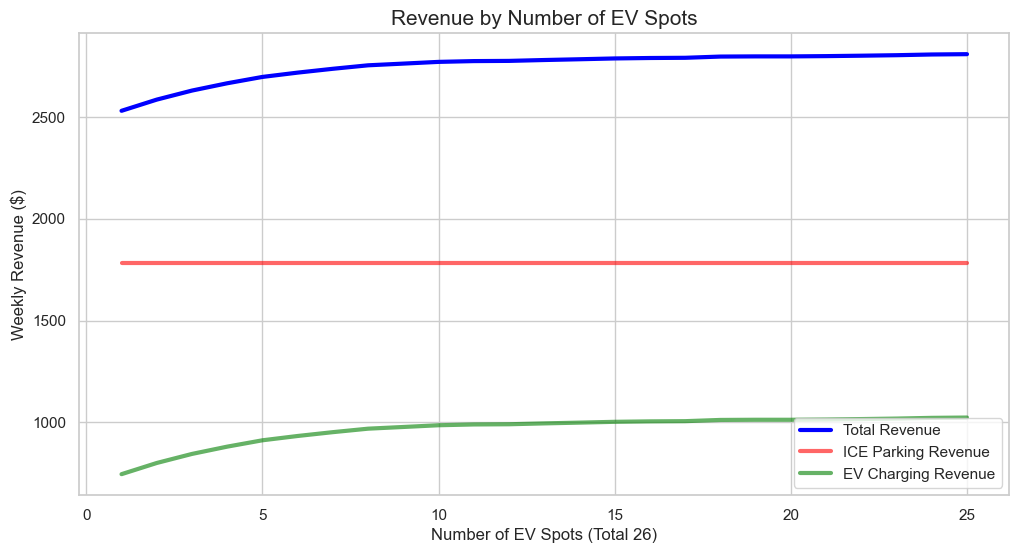

In [107]:
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='ev_spots', y='total_revenue',  color='blue', linewidth=3, label='Total Revenue')

sns.lineplot(data=df, x='ev_spots', y='ice_revenue', label='ICE Parking Revenue', color='red', linewidth=3, alpha=0.6)
sns.lineplot(data=df, x='ev_spots', y='ev_total_revenue', label='EV Charging Revenue',color='green', linewidth=3, alpha=0.6)

plt.title("Revenue by Number of EV Spots", fontsize=15)
plt.xlabel("Number of EV Spots (Total 26)", fontsize=12)
plt.ylabel("Weekly Revenue ($)", fontsize=12)
plt.legend(frameon=True)

plt.savefig("on_demand_revenue.png", dpi=300, bbox_inches='tight')
plt.show()

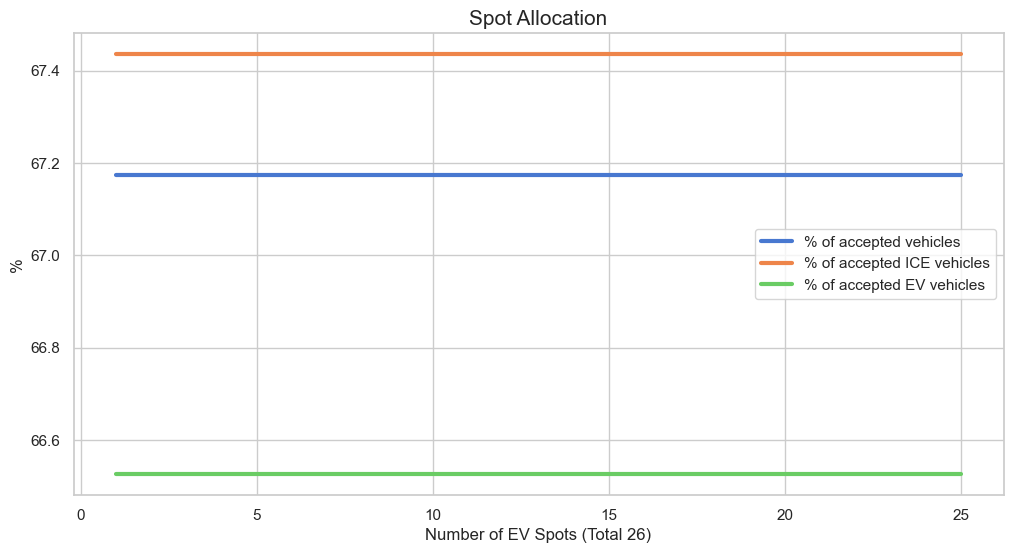

In [108]:
# Set a modern theme
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(12, 6))

# Plot total revenue
sns.lineplot(data=df, x='ev_spots', y='accepted_ratio_full', linewidth=3 ,label='% of accepted vehicles')
sns.lineplot(data=df, x='ev_spots', y='accepted_ice_full',  linewidth=3,label='% of accepted ICE vehicles')
sns.lineplot(data=df, x='ev_spots', y='accepted_ev_full', linewidth=3,label='% of accepted EV vehicles')

plt.title("Spot Allocation", fontsize=15)
plt.xlabel("Number of EV Spots (Total 26)", fontsize=12)
plt.ylabel("%", fontsize=12)
plt.legend(frameon=True)

plt.savefig("on_demand_allocation.png", dpi=300, bbox_inches='tight')

plt.show()

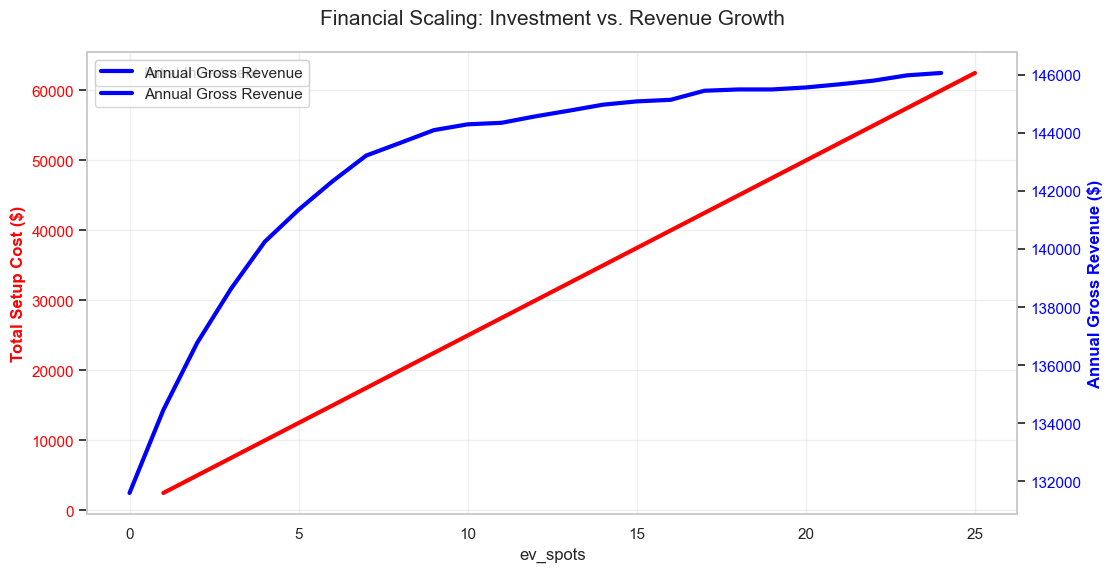

In [109]:
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.lineplot(data=df, x='ev_spots', y='cost', color='red', 
             linewidth=3, label='Initial Investment', ax=ax1)
ax1.set_ylabel('Total Setup Cost ($)', fontsize=12, color='red', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
sns.lineplot(data=df, x=df.index, y='yearly_rev', color='blue', 
             linewidth=3, label='Annual Gross Revenue', ax=ax2)
ax2.set_ylabel('Annual Gross Revenue ($)', fontsize=12, color='blue', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Financial Scaling: Investment vs. Revenue Growth", fontsize=15, pad=20)
ax1.grid(True, alpha=0.3)
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.savefig("on_demand_cost_rev.png", dpi=300, bbox_inches='tight')

plt.show()

In [145]:
# --- 1. PREPARE NORMALIZED DATA ---
# Define the safe normalization helper to prevent NaN crashes
def safe_normalize(series):
    if series.max() == series.min():
        return 0.0
    return (series - series.min()) / (series.max() - series.min())

# Calculate normalized components
df['norm_rev']  = safe_normalize(df['yearly_rev'])
df['norm_ev_occ']  = safe_normalize(df['accepted_ev_full'])
df['norm_ice_occ']  = safe_normalize(df['accepted_ice_full'])

# Cost logic: 1 is cheap (good), 0 is expensive (bad)
df['norm_cost'] = 1 - safe_normalize(df['cost'])

# --- 2. CALCULATE BALANCE SCORE ---
df['balance_score'] = (df['norm_rev'] * 0.4) + (df['norm_ev_occ'] * 0.2) + (df['norm_ice_occ'] * 0.2) + (df['norm_cost'] * 0.2)

# --- 3. FIND THE BEST INDICES ---8
# Handle the case where On-Demand might produce identical scores
if df['balance_score'].isna().all() or (df['balance_score'].max() == df['balance_score'].min()):
    # If all are equal, default to the configuration with the lowest cost (index 0)
    best_balance_idx = df['cost'].idxmin() 
else:
    best_balance_idx = df['balance_score'].idxmax()

best_profit_idx  = df['yearly_rev'].idxmax()
best_occ_idx     = df['accepted_ratio_full'].idxmax()

# --- 4. EXTRACT VALUES ---
suggested_spots = df.loc[best_balance_idx, 'ev_spots']
max_profit_spots = df.loc[best_profit_idx, 'ev_spots']
max_occ_spots    = df.loc[best_occ_idx, 'ev_spots']

# --- 5. PRINT SUMMARY ---
print(f"=== OPTIMIZATION RESULTS ({ev_scheme.upper()}) ===")
print(f"Max Profit Goal     -> {max_profit_spots} Spots | Rev: ${df.loc[best_profit_idx, 'yearly_rev']:,.0f}")
print(f"Max Occupancy Goal  -> {max_occ_spots} Spots | Occ: {df.loc[best_occ_idx, 'accepted_ratio_full']:.1f}%")
print(f"Minimum Cost Goal   -> {df['ev_spots'].min()} Spots | Cost: ${df['cost'].min():,.0f}")
print("-" * 45)

# Extract stats for the Suggested Balance
suggested_rev = df.loc[best_balance_idx, 'yearly_rev']
suggested_occ = df.loc[best_balance_idx, 'accepted_ratio_full']

print(f"SUGGESTED BALANCE   -> {suggested_spots} EV Spots")
print(f"Revenue:             ${suggested_rev:,.2f}")
print(f"Occupancy:           {suggested_occ:.2f}%")
print(f"Balance Score:       {df.loc[best_balance_idx, 'balance_score']:.4f}")
print(f"Description: Best trade-off between Rev, Occupancy, and CapEx.")

=== OPTIMIZATION RESULTS (PRIORITY) ===
Max Profit Goal     -> 7 Spots | Rev: $142,769
Max Occupancy Goal  -> 3 Spots | Occ: 66.3%
Minimum Cost Goal   -> 1 Spots | Cost: $2,500
---------------------------------------------
SUGGESTED BALANCE   -> 7 EV Spots
Revenue:             $142,768.60
Occupancy:           66.16%
Balance Score:       0.8547
Description: Best trade-off between Rev, Occupancy, and CapEx.


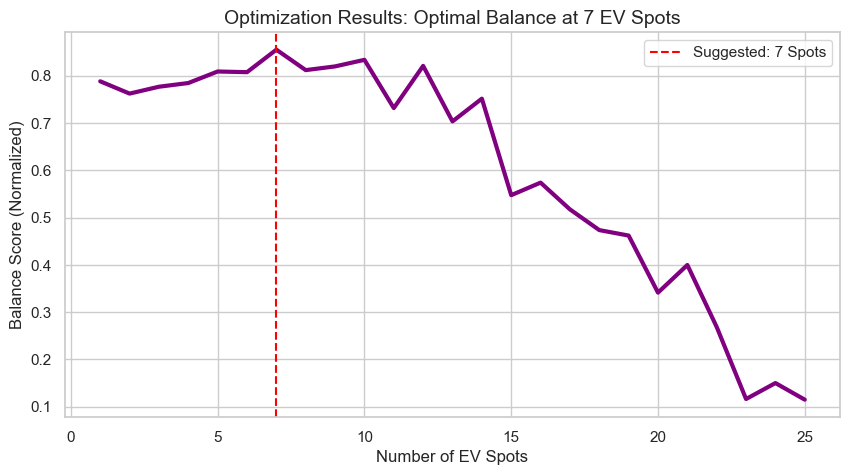

In [146]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='ev_spots', y='balance_score', linewidth=3, color='purple')

plt.axvline(x=suggested_spots, color='red', linestyle='--', label=f'Suggested: {suggested_spots} Spots')

plt.title(f"Optimization Results: Optimal Balance at {suggested_spots} EV Spots", fontsize=14)
plt.xlabel("Number of EV Spots")
plt.ylabel("Balance Score (Normalized)")
plt.legend()

plt.savefig("on_demand - ideal.png", dpi=300, bbox_inches='tight')
plt.show()

In [132]:
static_results = []
prices = np.arange(0.5, 2, 0.01)

for price in prices:
    current_sim = sim.ParkingSimulation(
        num_regular_spots=CAPACITY - OPTIMAL_SPOTS, 
        num_ev_spots=OPTIMAL_SPOTS, 
        ev_scheme=ev_scheme, 
        static_pricing=True, 
        alpha=1.0, 
        base_rate=price
    )
    
    current_sim.run(visualize=False)
    
    total_rev = current_sim.revenue_ice + current_sim.revenue_ev_parking + current_sim.revenue_ev_charging
    
    
    total_accepted = current_sim.accepted_ice + current_sim.accepted_ev
    total_rejected = (current_sim.rejected_ice_full + current_sim.rejected_ice_price + 
                      current_sim.rejected_ev_full + current_sim.rejected_ev_price)
    total_attempts = total_accepted + total_rejected
    
    accepted_ratio = (total_accepted / total_attempts) if total_attempts > 0 else 0

    static_results.append({
        "base_rate": price,
        "total_yearly_rev": total_rev,
        "accepted_ratio": accepted_ratio, 
        "accepted_ice": current_sim.accepted_ice,
        "accepted_ev": current_sim.accepted_ev,
        "cost": current_sim.setup_cost
    })

df_static = pd.DataFrame(static_results)

df_static['norm_rev'] = norm(df_static['total_yearly_rev'])
df_static['norm_acc'] = norm(df_static['accepted_ratio'])

df_static['balance_score'] = (df_static['norm_rev'] * 0.5) + (df_static['norm_acc'] * 0.5)

best_static_idx = df_static['balance_score'].idxmax()
best_price = df_static.loc[best_static_idx, 'base_rate']

print(f"--- STATIC OPTIMIZATION (ACC. RATIO FOCUS) ---")
print(f"Optimal Price:     €{best_price:.2f}/h")
print(f"Total Revenue:     €{df_static.loc[best_static_idx, 'total_yearly_rev']:,.2f}")
print(f"Accepted Ratio:    {df_static.loc[best_static_idx, 'accepted_ratio'] * 100:.2f}%")

--- STATIC OPTIMIZATION (ACC. RATIO FOCUS) ---
Optimal Price:     €1.40/h
Total Revenue:     €2,701.73
Accepted Ratio:    68.45%


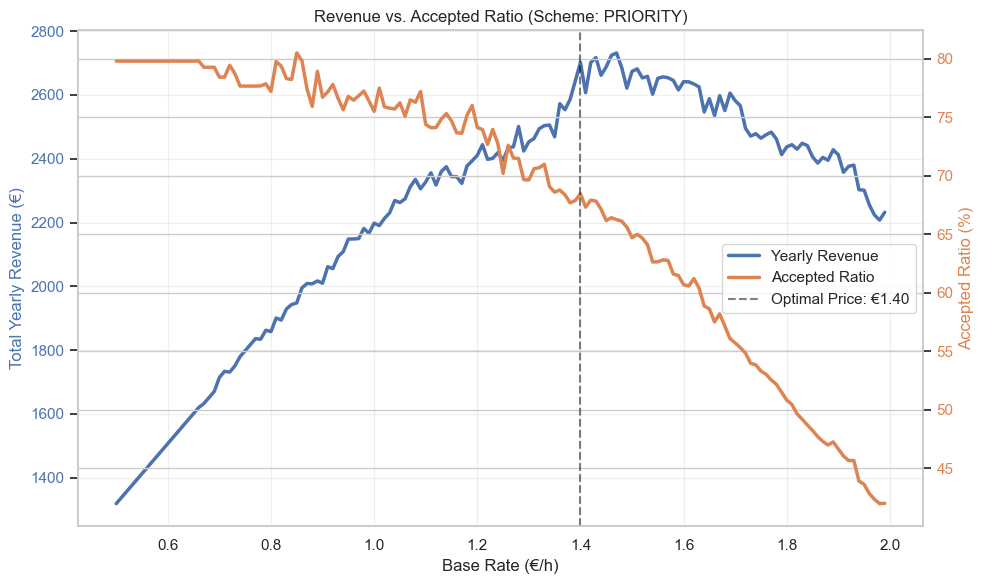

In [134]:
import matplotlib.pyplot as plt

# --- 4. VISUALIZATION ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Axis: Revenue
ax1.set_xlabel('Base Rate (€/h)', fontsize=12)
ax1.set_ylabel('Total Yearly Revenue (€)', color='C0', fontsize=12)
ax1.plot(df_static['base_rate'], df_static['total_yearly_rev'], color='C0', linewidth=2.5, label='Yearly Revenue')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.grid(True, linestyle='-', alpha=0.3)

# Secondary Axis: Accepted Ratio
ax2 = ax1.twinx() 
ax2.set_ylabel('Accepted Ratio (%)', color='C1', fontsize=12)
ax2.plot(df_static['base_rate'], df_static['accepted_ratio'] * 100, color='C1', linewidth=2.5, label='Accepted Ratio')
ax2.tick_params(axis='y', labelcolor='C1')

# Mark the Optimal Point
best_price = df_static.loc[df_static['balance_score'].idxmax(), 'base_rate']
plt.axvline(x=best_price, color='black', linestyle='--', alpha=0.5, label=f'Optimal Price: €{best_price:.2f}')

# Title and Layout
plt.title(f'Revenue vs. Accepted Ratio (Scheme: {ev_scheme.upper()})')
fig.tight_layout()

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.savefig("static- ideal.png", dpi=300, bbox_inches='tight')

plt.show()

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CAPACITY = 26
OPTIMAL_SPOTS = 8
base_rates = np.arange(1.0, 5.0, 0.1)  
alphas = np.arange(0.2, 2.2, 0.2)      
dynamic_results = []

print("--- STARTING DYNAMIC GRID SEARCH ---")

for br in base_rates:
    for a in alphas:
        current_sim = sim.ParkingSimulation(
            num_regular_spots=CAPACITY - OPTIMAL_SPOTS, 
            num_ev_spots=OPTIMAL_SPOTS, 
            ev_scheme="priority", 
            static_pricing=False,
            alpha=a, 
            base_rate=br
        )
        
        current_sim.run(visualize=False)
        
        total_rev = current_sim.revenue_ice + current_sim.revenue_ev_parking + current_sim.revenue_ev_charging
        
        total_accepted = current_sim.accepted_ice + current_sim.accepted_ev
        total_rejected = (current_sim.rejected_ice_full + current_sim.rejected_ice_price + 
                          current_sim.rejected_ev_full + current_sim.rejected_ev_price)
        total_attempts = total_accepted + total_rejected
        
        accepted_ratio = (total_accepted / total_attempts) if total_attempts > 0 else 0
        
        dynamic_results.append({
            "base_rate": br,
            "alpha": a,
            "total_rev": total_rev,
            "accepted_ratio": accepted_ratio
        })

df_dyn = pd.DataFrame(dynamic_results)

def norm(series):
    if series.max() == series.min(): return series * 0
    return (series - series.min()) / (series.max() - series.min())

df_dyn['norm_rev'] = norm(df_dyn['total_rev'])
df_dyn['norm_acc'] = norm(df_dyn['accepted_ratio'])

df_dyn['score'] = (df_dyn['norm_rev'] * 0.5) + (df_dyn['norm_acc'] * 0.5)

best_idx = df_dyn['score'].idxmax()
best_config = df_dyn.loc[best_idx]

print(f"--- DYNAMIC OPTIMIZATION COMPLETE ---")
print(f"Best Base Rate:    €{best_config['base_rate']:.2f}")
print(f"Best Alpha:        {best_config['alpha']:.1f}")
print("-" * 30)
print(f"Peak Revenue:      €{best_config['total_rev']:,.2f}")
print(f"Accepted Ratio:    {best_config['accepted_ratio'] * 100:.2f}%")
print(f"Balance Score:     {best_config['score']:.4f}")

--- STARTING DYNAMIC GRID SEARCH ---
--- DYNAMIC OPTIMIZATION COMPLETE ---
Best Base Rate:    €1.30
Best Alpha:        1.0
------------------------------
Peak Revenue:      €2,559.05
Accepted Ratio:    72.05%
Balance Score:     0.9101


In [139]:
from mpl_toolkits.mplot3d import Axes3D

# 1. Pivot the data so Base Rates are one axis and Alphas are the other
# We use the results from your Dynamic Grid Search
pivot_df = df_dyn.pivot(index='base_rate', columns='alpha', values='total_rev')

# 2. Create the coordinate matrices
X = pivot_df.columns.values  # Alphas
Y = pivot_df.index.values    # Base Rates
X, Y = np.meshgrid(X, Y)
Z = pivot_df.values          # Revenue

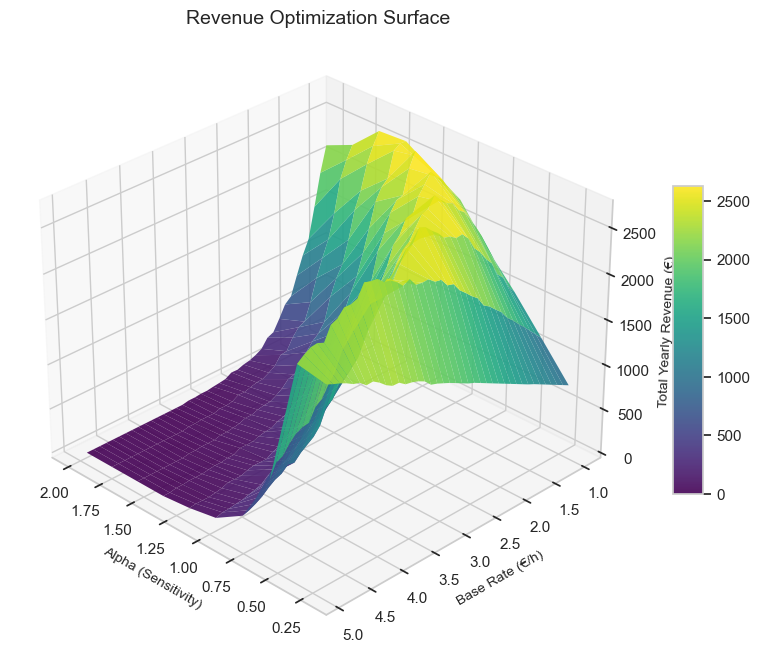

In [140]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

# Add labels
ax.set_xlabel('Alpha (Sensitivity)', fontsize=10)
ax.set_ylabel('Base Rate (€/h)', fontsize=10)
ax.set_zlabel('Total Yearly Revenue (€)', fontsize=10)
ax.set_title('Revenue Optimization Surface', fontsize=14)

# Add a color bar
fig.colorbar(surf, shrink=0.5, aspect=10)

# Adjust the viewing angle to see the peak clearly
ax.view_init(elev=30, azim=135)

plt.savefig("price_optimization_chart_dyn_1.png", dpi=300)
plt.show()

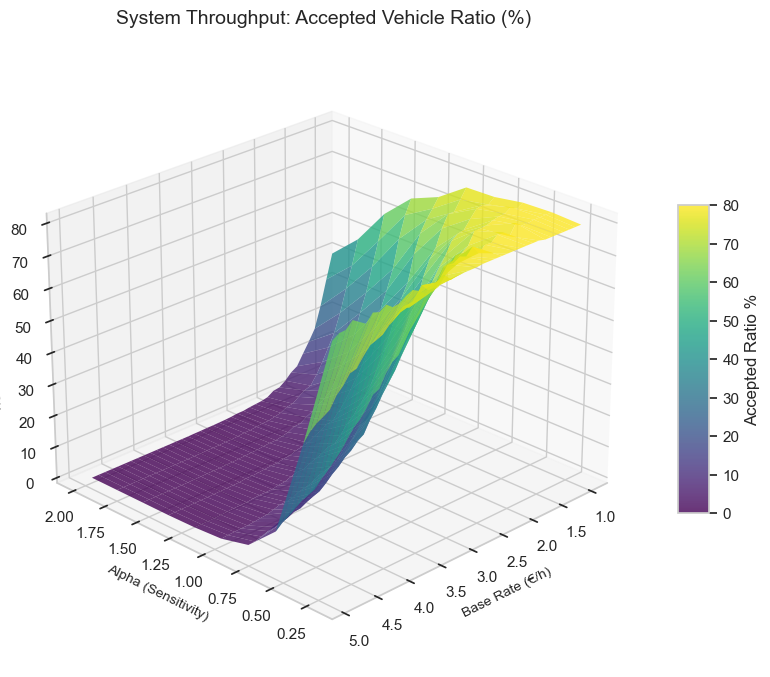

In [142]:
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.pyplot as plt

# 1. Pivot with Alpha as index and Base Rate as columns
# Now using 'accepted_ratio' instead of 'fullness'
pivot_ratio = df_dyn.pivot(index='alpha', columns='base_rate', values='accepted_ratio')

# 2. Create Matrices
X_price = pivot_ratio.columns.values
Y_alpha = pivot_ratio.index.values
X_price, Y_alpha = np.meshgrid(X_price, Y_alpha)
Z_ratio = pivot_ratio.values * 100  # Convert to percentage

# 3. Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot surface - Using 'viridis' for a professional look
surf = ax.plot_surface(X_price, Y_alpha, Z_ratio, cmap='viridis', edgecolor='none', alpha=0.8)

# Labels
ax.set_xlabel('Base Rate (€/h)', fontsize=10)
ax.set_ylabel('Alpha (Sensitivity)', fontsize=10)
ax.set_zlabel('Accepted Ratio (%)', fontsize=10)
ax.set_title('System Throughput: Accepted Vehicle Ratio (%)', fontsize=14, pad=20)

# --- THE SCALE FLIP ---
# Keeps the orientation consistent with your previous analysis
ax.invert_yaxis()

# Color Bar
fig.colorbar(surf, shrink=0.5, aspect=10, label='Accepted Ratio %')

# View angle
ax.view_init(elev=25, azim=45)

plt.savefig("dynamic_throughput_3d.png", dpi=300)
plt.show()